# National trends in peak annual streamflow

## Introduction

This notebook demonstrates a slightly more advanced application of the `dataretrieval.waterdata` module: assembling a dataset of historical annual peak streamflow and regressing peak discharge against time to look for trends — not at a single station, but across many.

## Setup
Before we begin any analysis, we'll need to set up our environment by importing a few modules.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

from dataretrieval import waterdata

## Basic usage
The `waterdata` module is the recommended interface to USGS water data and replaces the deprecated `nwis` module. Annual peak streamflow is retrieved with `waterdata.get_peaks()`, which returns a `pandas` data frame and a metadata object. To get started we need a monitoring location ID, a parameter code, and (optionally) a time window.

In [2]:
# download annual peaks (discharge, parameter 00060) from a single site
df, md = waterdata.get_peaks(
    monitoring_location_id="USGS-03339000",
    parameter_code="00060",
    time="1970-01-01/..",
)
df.head()

Retrieving: peaks · 1 page · 56 rows


No API key detected — register for higher rate limits at https://api.waterdata.usgs.gov/signup/


,geometry,time_series_id,monitoring_location_id,parameter_code,unit_of_measure,value,last_modified,time,water_year,year,month,day,time_of_day,peak_since,qualifier,peak_id
0,POINT (-87.59761 40.10108),1587ac4ee41d4f6b9debe9724e8ddb79,USGS-03339000,00060,ft^3/s,16300,2026-04-28 09:40:12.927288+00:00,1970-04-20,1970,1970,4,20,NaN,None,[UNKNOWNREGULATION],5282b66f-ee19-43d9-b772-936da66a968d
1,POINT (-87.59761 40.10108),1587ac4ee41d4f6b9debe9724e8ddb79,USGS-03339000,00060,ft^3/s,8910,2026-04-28 09:40:12.927288+00:00,1971-02-05,1971,1971,2,5,NaN,None,[UNKNOWNREGULATION],935a7d88-6e6c-4b80-b6a2-20b909d6e67f
2,POINT (-87.59761 40.10108),1587ac4ee41d4f6b9debe9724e8ddb79,USGS-03339000,00060,ft^3/s,9240,2026-04-28 09:40:12.927288+00:00,1972-04-22,1972,1972,4,22,NaN,None,[UNKNOWNREGULATION],69975ecd-959a-46bc-a221-815c947a76b6
3,POINT (-87.59761 40.10108),1587ac4ee41d4f6b9debe9724e8ddb79,USGS-03339000,00060,ft^3/s,16600,2026-04-28 09:40:12.927288+00:00,1973-04-23,1973,1973,4,23,NaN,None,[UNKNOWNREGULATION],55fc2bdd-fc45-44d5-b291-6767e5e44ff6
4,POINT (-87.59761 40.10108),1587ac4ee41d4f6b9debe9724e8ddb79,USGS-03339000,00060,ft^3/s,19500,2026-04-28 09:40:12.927288+00:00,1974-06-23,1974,1974,6,23,NaN,None,[UNKNOWNREGULATION],c202f21a-a940-418f-92d6-253598a16dd0


All we require for the trend analysis are the peak date (`time`), the monitoring location ID (`monitoring_location_id`), and the peak streamflow (`value`). The Water Data API returns a flat (single-index) data frame with one row per annual peak.

## Preparing the regression
Next we'll define a function that applies ordinary least squares to peak discharge versus time. After grouping the dataset by `monitoring_location_id`, we apply the regression per monitoring location. Each location's result is returned as a row with the slope, y-intercept, p value, and standard error of the regression.

In [3]:
def peak_trend_regression(df):
    # convert peak dates to days since the first peak for the regression
    peak_date = pd.to_datetime(df["time"])
    peak_d = (peak_date - peak_date.min()) / np.timedelta64(1, "D")

    # normalize the peak discharge values
    value = (df["value"] - df["value"].mean()) / df["value"].std()

    slope, intercept, _r_value, p_value, std_error = stats.linregress(peak_d, value)

    return pd.Series(
        {
            "slope": slope,
            "intercept": intercept,
            "p_value": p_value,
            "std_error": std_error,
        }
    )

## Preparing the analysis

In [4]:
def peak_trend_analysis(state_names, start_date):
    """
    state_names : list
        state names to include in the analysis, e.g. ["Illinois", "Indiana"].
    start_date : string
        the date to use as the beginning of the analysis (YYYY-MM-DD).
    """
    frames = []

    for state in state_names:
        # find stream gages in the state (keep the geometry for mapping)
        sites, _ = waterdata.get_monitoring_locations(
            state_name=state, site_type_code="ST"
        )
        # download annual peak discharge for those sites
        df, _ = waterdata.get_peaks(
            monitoring_location_id=sites["monitoring_location_id"].tolist(),
            parameter_code="00060",
            time=f"{start_date}/..",
        )
        # group the data by site and apply our regression
        temp = (
            df.groupby("monitoring_location_id")
            .apply(peak_trend_regression)
            .dropna()
        )
        # drop any insignificant results
        temp = temp[temp["p_value"] < 0.05]

        # join site geometry/metadata with the trend results; GeoDataFrame.merge
        # keeps the joined result spatial
        merged = sites.merge(
            temp, right_index=True, left_on="monitoring_location_id"
        )
        frames.append(merged)

    return pd.concat(frames, ignore_index=True)

Running the analysis for every state since 1970 would pull a large amount of data from the Water Data API and could burden the service. To keep this demo light, we run a single small state — Rhode Island — below.

In [5]:
# Download peak discharge for every stream gage in Rhode Island and run the
# trend regression on each. For larger states the async chunker (default
# concurrency 16) automatically fans the ``get_peaks`` call across many sites;
# Rhode Island is small enough to return in a single request.
start = "1970-01-01"
states = ["Rhode Island"]
final_df = peak_trend_analysis(state_names=states, start_date=start)
final_df.head()

Retrieving: monitoring-locations · 1 page · 351 rows

Retrieving: peaks · 1 page · 1,308 rows

,monitoring_location_id,geometry,agency_code,agency_name,monitoring_location_number,monitoring_location_name,district_code,country_code,country_name,state_code,...,well_constructed_depth,hole_constructed_depth,depth_source_code,revision_note,revision_created,revision_modified,slope,intercept,p_value,std_error
0,USGS-01114000,POINT (-71.41061 41.83399),USGS,U.S. Geological Survey,01114000,"MOSHASSUCK RIVER AT PROVIDENCE, RI",25,US,United States of America,44,...,NaN,NaN,None,"WDR MA-RI, water years 1964-1973, annual peak ...",2017-11-13T06:00:00+00:00,2022-04-07T14:31:13.870000+00:00,0.000059,-0.588666,0.008529,0.000022
1,USGS-01115098,POINT (-71.60618 41.8526),USGS,U.S. Geological Survey,01115098,PEEPTOAD BROOK AT ELMDALE RD NR NORTH SCITUATE...,25,US,United States of America,44,...,NaN,NaN,None,WDR MA-RI-03-01: Drainage area.,2017-11-13T06:00:00+00:00,NaN,0.000153,-0.846482,0.003592,0.000048
2,USGS-01115200,POINT (-71.75035 41.83121),USGS,U.S. Geological Survey,01115200,"SHIPPEE BROOK TRIBUTARY AT NORTH FOSTER, RI",25,US,United States of America,44,...,NaN,NaN,None,NaN,NaN,NaN,-0.001714,1.103788,0.000945,0.000130
3,USGS-01117250,POINT (-71.53944 41.43222),USGS,U.S. Geological Survey,01117250,"BROWNS BROOK AT WAKEFIELD, RI",25,US,United States of America,44,...,NaN,NaN,None,NaN,NaN,NaN,-0.001486,1.175513,0.044431,0.000445


The cell above ran the full analysis for a single small state (Rhode Island) and returned `final_df` — one row per gage whose peak-discharge trend is statistically significant (`p_value < 0.05`), carrying the regression slope, intercept, p-value, and standard error.

`final_df` pairs each station's trend statistics with its monitoring-location metadata (`monitoring_location_id`, `state_name`, `site_type_code`, …) and, because we kept the locations' geometry, a `geometry` column of point coordinates — so we can map the results directly.

## Plotting the results
Because `final_df` is a `GeoDataFrame`, we can map the results directly with geopandas and `matplotlib` — no extra basemap stack required. Monitoring locations with increasing peak annual discharge are shown in red, and those with decreasing peaks in blue.

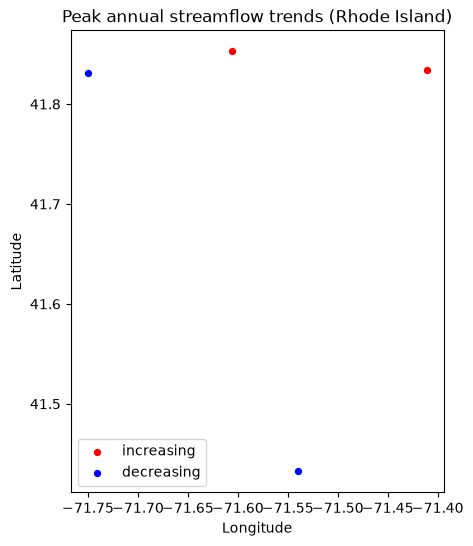

In [6]:
import matplotlib.pyplot as plt

# final_df is a GeoDataFrame, so its station points plot directly.
increasing = final_df[final_df["slope"] > 0]
decreasing = final_df[final_df["slope"] < 0]

fig, ax = plt.subplots(figsize=(8, 6))
if not increasing.empty:
    increasing.plot(ax=ax, color="red", markersize=18, label="increasing")
if not decreasing.empty:
    decreasing.plot(ax=ax, color="blue", markersize=18, label="decreasing")
ax.set_title(f"Peak annual streamflow trends ({', '.join(states)})")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
plt.show()